# Part 1: Architecture + Tokenization + Pre-training
**LLMForge | IISc LLM Course**

This notebook covers:
- Custom BPE tokenizer training
- TinyGPT from scratch (modular architecture)
- Pre-training with live metrics

In [2]:
# Install dependencies
!pip install tokenizers transformers datasets torch torchvision torchaudio -q
!pip install gradio chromadb sentence-transformers PyMuPDF pyyaml -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys, os
sys.path.insert(0, '..')  # Add project root
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch: 2.11.0+cu130
CUDA: False


## 1.1 Custom BPE Tokenizer

We train a domain-specific tokenizer on our text corpus.
Inspired by the tokenization module — compare compression ratios.

In [4]:
from src.data.tokenizer import CustomTokenizer

# Option A: Train from scratch on custom text
import os
os.makedirs('data', exist_ok=True)

# Write a sample corpus (replace with your PDFs or text files)
sample_corpus = '''
The transformer architecture introduced in 'Attention is All You Need' uses
self-attention mechanisms to process sequences in parallel. Unlike RNNs,
transformers can attend to all positions simultaneously using scaled
dot-product attention. The key innovation is the multi-head attention
mechanism that allows the model to jointly attend to information from
different representation subspaces.

Large language models like GPT-2 are trained on massive text corpora
using the causal language modeling objective: predict the next token
given all previous tokens. This autoregressive training enables the
model to generate coherent text.
'''
with open('data/sample_corpus.txt', 'w') as f:
    f.write(sample_corpus * 100)  # Repeat for demo

# Train BPE tokenizer
custom_tok = CustomTokenizer.train(
    source='data/sample_corpus.txt',
    vocab_size=1000,  # Small for demo; use 8000+ for real training
    min_frequency=2,
    save_path='data/custom_tokenizer'
)
print(f'\nCustom tokenizer: {custom_tok}')

# Option B: Load GPT-2 tokenizer
gpt2_tok = CustomTokenizer.from_pretrained('gpt2')
print(f'GPT-2 tokenizer: {gpt2_tok}')

Training BPE tokenizer on 1 file(s) | vocab_size=1000



Tokenizer saved → data/custom_tokenizer
Compression ratio: 5.47 chars/token

Custom tokenizer: CustomTokenizer(vocab_size=527, is_hf=False)
Loaded tokenizer: gpt2 | vocab=50,257
GPT-2 tokenizer: CustomTokenizer(vocab_size=50257, is_hf=True)


In [5]:
# Compare compression ratios
test_sentence = 'The attention mechanism uses query key value projections to compute weighted sums'

custom_tokens = custom_tok.encode(test_sentence)
gpt2_tokens   = gpt2_tok.encode(test_sentence)

print(f'Test: "{test_sentence}"')
print(f'  Custom BPE (vocab={custom_tok.vocab_size}): {len(custom_tokens)} tokens')
print(f'  GPT-2 BPE  (vocab={gpt2_tok.vocab_size}): {len(gpt2_tokens)} tokens')
print(f'  Compression: {len(test_sentence)/len(custom_tokens):.2f} vs {len(test_sentence)/len(gpt2_tokens):.2f} chars/token')

# Round-trip test
reconstructed = custom_tok.decode(custom_tokens)
print(f'\nRound-trip test:')
print(f'  Original     : {test_sentence}')
print(f'  Reconstructed: {reconstructed}')

Test: "The attention mechanism uses query key value projections to compute weighted sums"
  Custom BPE (vocab=527): 39 tokens
  GPT-2 BPE  (vocab=50257): 12 tokens
  Compression: 2.08 vs 6.75 chars/token

Round-trip test:
  Original     : The attention mechanism uses query key value projections to compute weighted sums
  Reconstructed: The attention mechanism uses query key value projections to compute weighted sums


## 1.2 Modular Architecture

Build 4 different architectures by swapping components.
Inspired by [buildanllm.com](https://buildanllm.com) — every component is swappable.

In [6]:
from src.model import TransformerLM, ModelConfig
from src.components.registry import Registry
import src.components.norms, src.components.positional
import src.components.activations, src.components.attention

# Show all registered swappable components
Registry.summary()

Registered Components
  norm                : ['layernorm', 'rmsnorm']
  pos_encoding        : ['learned', 'rope', 'alibi', 'none']
  activation          : ['gelu', 'swiglu', 'relu', 'geglu']
  attention           : ['standard', 'grouped_query']


In [7]:
# Build 4 architectures — swap any component
presets = {
    'GPT-2 style': {'pos_encoding': 'learned', 'norm_type': 'layernorm', 'activation': 'gelu',   'attention_type': 'standard'},
    'LLaMA style': {'pos_encoding': 'rope',    'norm_type': 'rmsnorm',   'activation': 'swiglu', 'attention_type': 'grouped_query'},
    'OLMo style':  {'pos_encoding': 'alibi',   'norm_type': 'layernorm', 'activation': 'swiglu', 'attention_type': 'standard'},
    'Custom mix':  {'pos_encoding': 'rope',    'norm_type': 'rmsnorm',   'activation': 'gelu',   'attention_type': 'standard'},
}

print(f'{'Architecture':<15} {'Pos Enc':<10} {'Norm':<12} {'Activation':<10} {'Params':>10} {'FP16 MB':>10}')
print('-' * 70)
for name, cfg in presets.items():
    model = TransformerLM(ModelConfig(
        vocab_size=8000, d_model=256, n_heads=8, n_layers=6, d_ff=1024, **cfg
    ))
    total = sum(p.numel() for p in model.parameters())
    print(f'{name:<15} {cfg["pos_encoding"]:<10} {cfg["norm_type"]:<12} {cfg["activation"]:<10} {total/1e6:>9.2f}M {total*2/1e6:>9.1f}')

Architecture    Pos Enc    Norm         Activation     Params    FP16 MB
----------------------------------------------------------------------
[DEBUG] Building pos_encoding:learned with kwargs={'d_model': 256, 'd_head': 32, 'max_seq': 512, 'n_heads': 8, 'dropout': 0.1, 'theta': 10000.0}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 256}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 256}
[DEBUG] Building attention:standard with kwargs={'d_model': 256, 'n_heads': 8, 'n_kv_heads': None, 'dropout': 0.1}
[DEBUG] Building activation:gelu with kwargs={'d_model': 256, 'd_ff': 1024}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 256}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 256}
[DEBUG] Building attention:standard with kwargs={'d_model': 256, 'n_heads': 8, 'n_kv_heads': None, 'dropout': 0.1}
[DEBUG] Building activation:gelu with kwargs={'d_model': 256, 'd_ff': 1024}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 256}
[DEBUG] Building norm:la

In [8]:
# Forward pass — verify all architectures work
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = TransformerLM.from_preset('gpt2',
    vocab_size=1000, d_model=128, n_heads=4, n_layers=4, d_ff=512
).to(device)

B, T = 2, 64
x = torch.randint(0, 1000, (B, T)).to(device)
y = torch.randint(0, 1000, (B, T)).to(device)

with torch.no_grad():
    out = model(x, targets=y)

print(f'Input  shape: {x.shape}')
print(f'Logits shape: {out["logits"].shape}')
print(f'Loss        : {out["loss"].item():.4f}')
print(f'PPL         : {torch.exp(out["loss"]).item():.2f}')
print(f'Attn maps   : {len(out["attn_weights"])} layers x {out["attn_weights"][0].shape}')

[DEBUG] Building pos_encoding:learned with kwargs={'d_model': 128, 'd_head': 32, 'max_seq': 512, 'n_heads': 4, 'dropout': 0.1, 'theta': 10000.0}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building attention:standard with kwargs={'d_model': 128, 'n_heads': 4, 'n_kv_heads': None, 'dropout': 0.1}
[DEBUG] Building activation:gelu with kwargs={'d_model': 128, 'd_ff': 512}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building attention:standard with kwargs={'d_model': 128, 'n_heads': 4, 'n_kv_heads': None, 'dropout': 0.1}
[DEBUG] Building activation:gelu with kwargs={'d_model': 128, 'd_ff': 512}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building attention:standard with kwargs={'d_model': 128, 'n_heads': 4, 'n_kv_heads': None, 'dropout':

## 1.3 Pre-training Loop

In [10]:
from src.training.trainer import Trainer, TrainConfig
from src.data.loaders import make_dataloaders
import matplotlib.pyplot as plt

# Use GPT-2 tokenizer for pre-training demo
tok = CustomTokenizer.from_pretrained('gpt2')

# Build model
model = TransformerLM(ModelConfig(
    vocab_size=tok.vocab_size, d_model=128, n_heads=4,
    n_layers=4, d_ff=512, max_seq=256,
    pos_encoding='learned', norm_type='layernorm',
    activation='gelu', attention_type='standard'
))

# Training config
train_cfg = TrainConfig(
    optimizer='adamw',
    lr=3e-4,
    lr_schedule='cosine',
    warmup_steps=50,
    max_steps=500,   # Increase for real training
    batch_size=8,
    eval_every=100,
    save_every=250,
    precision='fp32',
    save_dir='data/checkpoints'
)

# Load TinyStories (small, fast to download)
train_dl, val_dl = make_dataloaders(
    'tinystories', tok._tok,
    batch_size=8, block_size=256, max_samples=5000
)

# Train!
trainer = Trainer(model, train_dl, val_dl, train_cfg, device=device)
metrics = trainer.train()

Loaded tokenizer: gpt2 | vocab=50,257
[DEBUG] Building pos_encoding:learned with kwargs={'d_model': 128, 'd_head': 32, 'max_seq': 256, 'n_heads': 4, 'dropout': 0.1, 'theta': 10000.0}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building attention:standard with kwargs={'d_model': 128, 'n_heads': 4, 'n_kv_heads': None, 'dropout': 0.1}
[DEBUG] Building activation:gelu with kwargs={'d_model': 128, 'd_ff': 512}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building attention:standard with kwargs={'d_model': 128, 'n_heads': 4, 'n_kv_heads': None, 'dropout': 0.1}
[DEBUG] Building activation:gelu with kwargs={'d_model': 128, 'd_ff': 512}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building norm:layernorm with kwargs={'d_model': 128}
[DEBUG] Building attention:standard with kwargs={'d_model': 128, 'n_hea

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1027718 > 1024). Running this sequence through the model will result in indexing errors


Dataset: tinystories | Train: 924,690 | Val: 102,516
Trainer ready | optimizer=adamw | schedule=cosine | precision=fp32

────────────────────────────────────────────────────────────
  Training: 500 steps | batch=8 | grad_accum=1
────────────────────────────────────────────────────────────

  step    50 | loss 9.3338 | ppl 11313.93 | grad 1.335 | lr 3.00e-04 | 1584 tok/s
  step   100 | loss 6.8939 | ppl 986.27 | grad 1.226 | lr 2.91e-04 | 1557 tok/s


/home/user/Downloads/LLMForge/notebooks/../src/training/trainer.py:247: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=self.dtype, enabled=self.use_amp):


  ✓ Val loss: 6.9064 | Val PPL: 998.69
  Saved checkpoint → data/checkpoints/ckpt_best.pt
  step   150 | loss 6.0398 | ppl 419.83 | grad 0.672 | lr 2.65e-04 | 1422 tok/s
  step   200 | loss 5.5966 | ppl 269.52 | grad 0.519 | lr 2.25e-04 | 1468 tok/s
  ✓ Val loss: 5.6939 | Val PPL: 297.06
  Saved checkpoint → data/checkpoints/ckpt_best.pt
  step   250 | loss 5.3819 | ppl 217.44 | grad 0.505 | lr 1.76e-04 | 1406 tok/s
  Saved checkpoint → data/checkpoints/ckpt_step_250.pt
  step   300 | loss 5.1476 | ppl 172.01 | grad 0.518 | lr 1.24e-04 | 1439 tok/s
  ✓ Val loss: 5.3511 | Val PPL: 210.85
  Saved checkpoint → data/checkpoints/ckpt_best.pt
  step   350 | loss 5.1820 | ppl 178.04 | grad 0.493 | lr 7.50e-05 | 1401 tok/s
  step   400 | loss 5.0208 | ppl 151.53 | grad 0.519 | lr 3.51e-05 | 1426 tok/s
  ✓ Val loss: 5.2255 | Val PPL: 185.95
  Saved checkpoint → data/checkpoints/ckpt_best.pt
  step   450 | loss 5.0514 | ppl 156.24 | grad 0.498 | lr 9.05e-06 | 1444 tok/s
  step   500 | loss 5.028

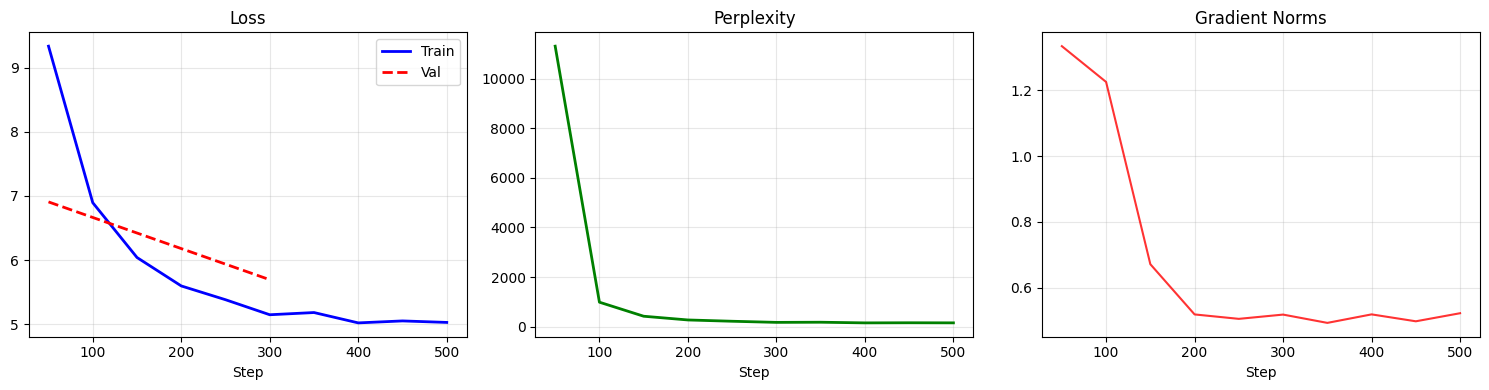

In [17]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(metrics.steps, metrics.train_loss, 'b-', lw=2, label='Train')
if metrics.val_loss:
    val_steps = metrics.steps[::5]
    n = min(len(val_steps), len(metrics.val_loss))
    axes[0].plot(val_steps[:n], metrics.val_loss[:n], 'r--', lw=2, label='Val')
    axes[0].legend()

axes[0].set_title('Loss'); axes[0].set_xlabel('Step'); axes[0].grid(alpha=0.3)
axes[1].plot(metrics.steps, metrics.perplexity, 'g-', lw=2)
axes[1].set_title('Perplexity'); axes[1].set_xlabel('Step'); axes[1].grid(alpha=0.3)
axes[2].plot(metrics.steps, metrics.grad_norms, 'r-', lw=1.5, alpha=0.8)
axes[2].set_title('Gradient Norms'); axes[2].set_xlabel('Step'); axes[2].grid(alpha=0.3)
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/part1_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Generate text from pre-trained model
import torch

model.eval()
prompt = 'Once upon a time'
ids    = tok.encode(prompt, return_tensors='pt').to(device)

with torch.no_grad():
    generated = model.generate(
        ids, max_new_tokens=50, temperature=0.8, top_k=40, do_sample=True
    )

text = tok.decode(generated[0].tolist())
print('Generated text:')
print('-' * 50)
print(text)

# Save checkpoint
model.save('data/checkpoints/part1_model.pt')
print('\nModel saved!')

Generated text:
--------------------------------------------------
Once upon a time, "




The little girl's said and she was a very boymy was very time.










The his park.












Saved → data/checkpoints/part1_model.pt

Model saved!
